# Loan Eligibility Prediction Using Logistic Regression

## Objective

The objective of this project is to predict whether a loan applicant is likely to repay the loan based on demographic, financial, and credit-related information.

## Tools Used

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Scikit-Learn
- Jupyter Notebook

## Target Variable

loan_paid_back

- 1 = Eligible / Loan Repaid
- 0 = Not Eligible / Loan Not Repaid

In [7]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

sns.set_style("whitegrid")

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [8]:
df = pd.read_csv(
    r"C:\Users\vaish\Downloads\loan_dataset_20000\loan_dataset_20000.csv"
)

df.head()

,age,gender,marital_status,education_level,annual_income,monthly_income,employment_status,debt_to_income_ratio,credit_score,loan_amount,...,loan_term,installment,grade_subgrade,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
0,59,Male,Married,Master's,24240.19,2020.02,Employed,0.074,743,17173.72,...,36,581.88,B5,7,40833.47,24302.07,1,0,1,1
1,72,Female,Married,Bachelor's,20172.98,1681.08,Employed,0.219,531,22663.89,...,60,573.17,F1,5,27968.01,10803.01,1,0,3,1
2,49,Female,Single,High School,26181.80,2181.82,Employed,0.234,779,3631.36,...,60,76.32,B4,2,15502.25,4505.44,0,0,0,1
3,35,Female,Single,High School,11873.84,989.49,Employed,0.264,809,14939.23,...,36,468.07,A5,7,18157.79,5525.63,4,0,5,1
4,63,Other,Single,Other,25326.44,2110.54,Employed,0.260,663,16551.71,...,60,395.50,D5,1,17467.56,3593.91,2,0,2,1


In [9]:
print("Dataset Shape :", df.shape)

print("\nColumns:\n")

print(df.columns.tolist())

Dataset Shape : (20000, 22)

Columns:

['age', 'gender', 'marital_status', 'education_level', 'annual_income', 'monthly_income', 'employment_status', 'debt_to_income_ratio', 'credit_score', 'loan_amount', 'loan_purpose', 'interest_rate', 'loan_term', 'installment', 'grade_subgrade', 'num_of_open_accounts', 'total_credit_limit', 'current_balance', 'delinquency_history', 'public_records', 'num_of_delinquencies', 'loan_paid_back']


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   age                   20000 non-null  int64  
 1   gender                20000 non-null  object 
 2   marital_status        20000 non-null  object 
 3   education_level       20000 non-null  object 
 4   annual_income         20000 non-null  float64
 5   monthly_income        20000 non-null  float64
 6   employment_status     20000 non-null  object 
 7   debt_to_income_ratio  20000 non-null  float64
 8   credit_score          20000 non-null  int64  
 9   loan_amount           20000 non-null  float64
 10  loan_purpose          20000 non-null  object 
 11  interest_rate         20000 non-null  float64
 12  loan_term             20000 non-null  int64  
 13  installment           20000 non-null  float64
 14  grade_subgrade        20000 non-null  object 
 15  num_of_open_account

In [11]:
df.describe()

,age,annual_income,monthly_income,debt_to_income_ratio,credit_score,loan_amount,interest_rate,loan_term,installment,num_of_open_accounts,total_credit_limit,current_balance,delinquency_history,public_records,num_of_delinquencies,loan_paid_back
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.00000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,48.027000,43549.637766,3629.136466,0.177019,679.25695,15129.300909,12.400626,43.22280,455.625794,5.011800,48649.824769,24333.394631,1.990150,0.061800,2.489150,0.799900
std,15.829352,28668.579671,2389.048326,0.105059,69.63858,8605.405513,2.442729,11.00838,274.622125,2.244529,32423.378128,22313.845395,1.474945,0.285105,1.631384,0.400085
min,21.000000,6000.000000,500.000000,0.010000,373.00000,500.000000,3.140000,36.00000,9.430000,0.000000,6157.800000,496.350000,0.000000,0.000000,0.000000,0.000000
25%,35.000000,24260.752500,2021.730000,0.096000,632.00000,8852.695000,10.740000,36.00000,253.910000,3.000000,27180.492500,9592.572500,1.000000,0.000000,1.000000,1.000000
50%,48.000000,36585.260000,3048.770000,0.160000,680.00000,14946.170000,12.400000,36.00000,435.595000,5.000000,40241.615000,18334.555000,2.000000,0.000000,2.000000,1.000000
75%,62.000000,54677.917500,4556.495000,0.241000,727.00000,20998.867500,14.002500,60.00000,633.595000,6.000000,60361.257500,31743.327500,3.000000,0.000000,3.000000,1.000000
max,75.000000,400000.000000,33333.330000,0.667000,850.00000,49039.690000,22.510000,60.00000,1685.400000,15.000000,454394.190000,352177.900000,11.000000,2.000000,11.000000,1.000000


In [12]:
df.isnull().sum()

age                     0
gender                  0
marital_status          0
education_level         0
annual_income           0
monthly_income          0
employment_status       0
debt_to_income_ratio    0
credit_score            0
loan_amount             0
loan_purpose            0
interest_rate           0
loan_term               0
installment             0
grade_subgrade          0
num_of_open_accounts    0
total_credit_limit      0
current_balance         0
delinquency_history     0
public_records          0
num_of_delinquencies    0
loan_paid_back          0
dtype: int64

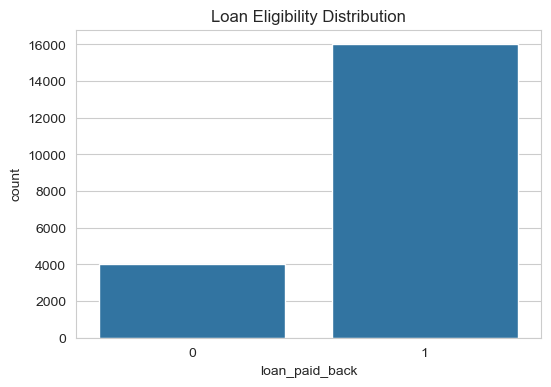

In [13]:
plt.figure(figsize=(6,4))

sns.countplot(
    x="loan_paid_back",
    data=df
)

plt.title("Loan Eligibility Distribution")

plt.show()

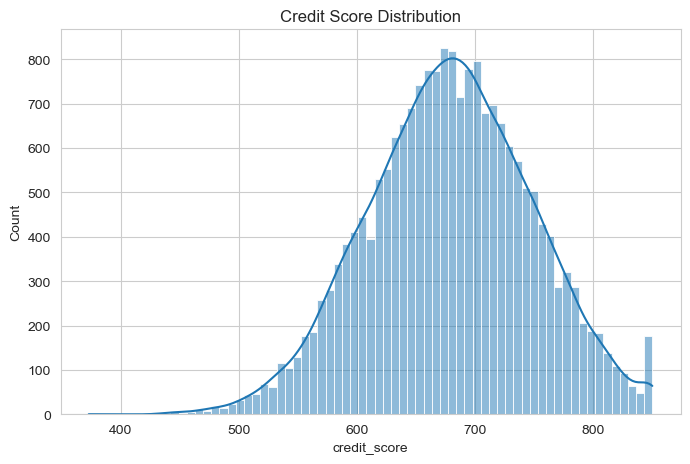

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="credit_score",
    kde=True
)

plt.title("Credit Score Distribution")

plt.show()

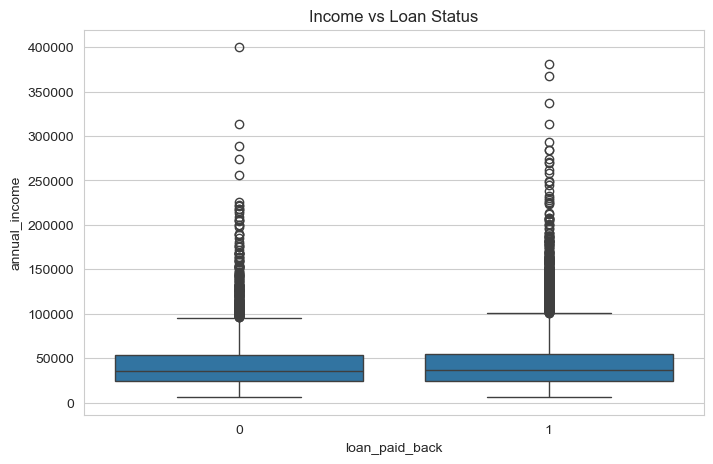

In [15]:
plt.figure(figsize=(8,5))

sns.boxplot(
    x="loan_paid_back",
    y="annual_income",
    data=df
)

plt.title("Income vs Loan Status")

plt.show()

In [16]:
categorical_columns = df.select_dtypes(
    include="object"
).columns

encoder = LabelEncoder()

for column in categorical_columns:
    df[column] = encoder.fit_transform(
        df[column]
    )

print("Encoding Completed")

Encoding Completed


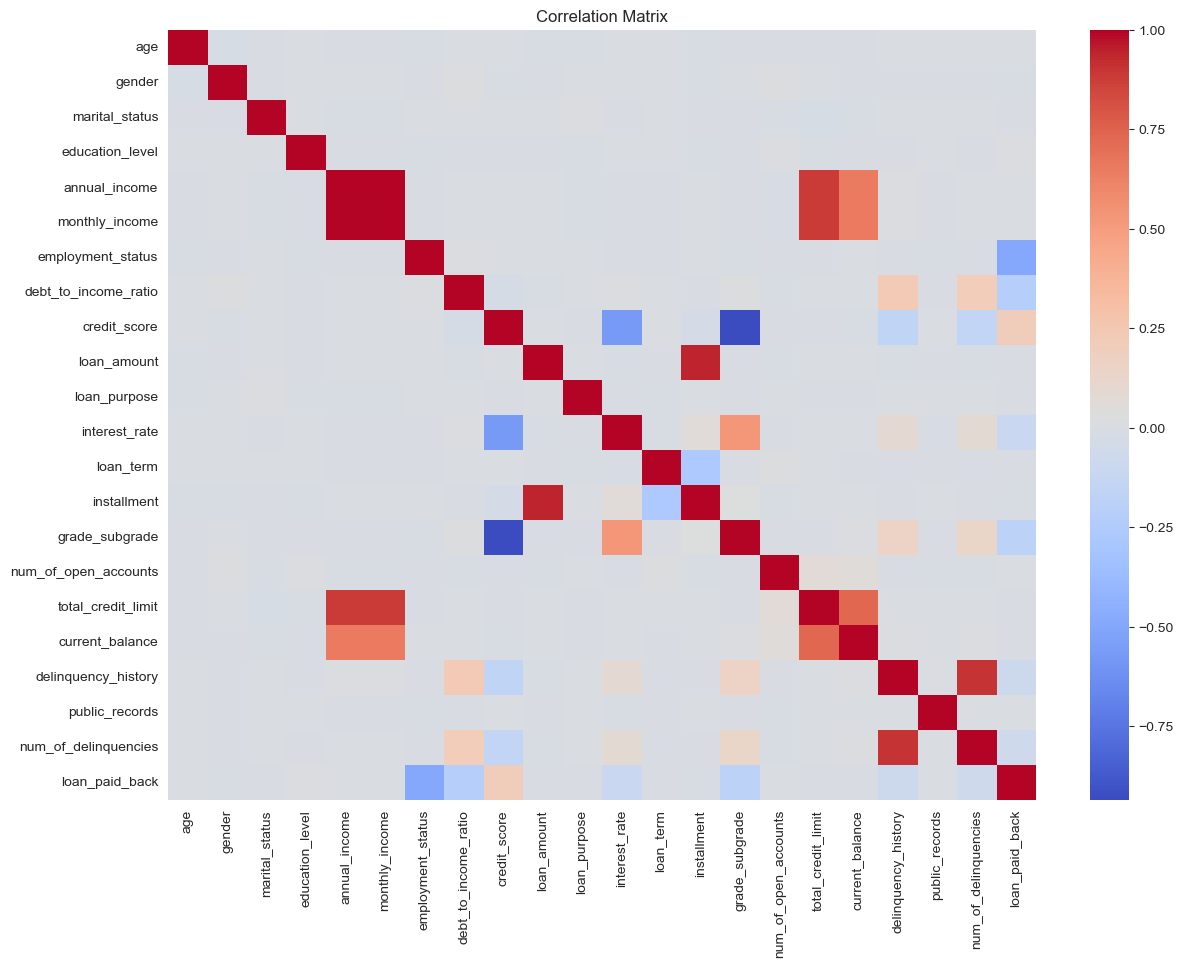

In [17]:
plt.figure(figsize=(14,10))

sns.heatmap(
    df.corr(),
    cmap="coolwarm"
)

plt.title("Correlation Matrix")

plt.show()

In [19]:
X = df.drop(
    "loan_paid_back",
    axis=1
)

y = df["loan_paid_back"]

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [21]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_test_scaled = scaler.transform(
    X_test
)

print("Scaling Completed")

Scaling Completed


In [22]:
loan_model = LogisticRegression(
    max_iter=1000
)

loan_model.fit(
    X_train_scaled,
    y_train
)

print("Model Trained Successfully")

Model Trained Successfully


In [23]:
predictions = loan_model.predict(
    X_test_scaled
)

predictions[:10]

array([1, 1, 1, 1, 1, 1, 1, 1, 1, 1])

In [24]:
accuracy = accuracy_score(
    y_test,
    predictions
)

print(
    "Model Accuracy:",
    round(accuracy * 100, 2),
    "%"
)

Model Accuracy: 88.35 %


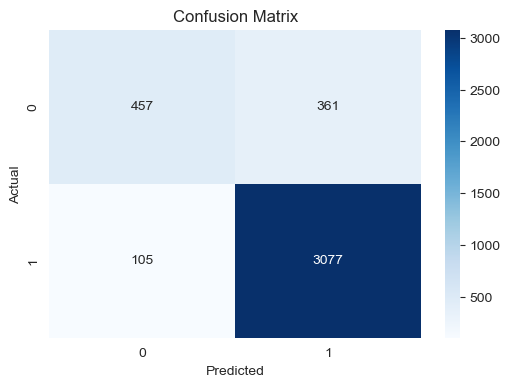

In [25]:
cm = confusion_matrix(
    y_test,
    predictions
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [26]:
print(
    classification_report(
        y_test,
        predictions
    )
)

              precision    recall  f1-score   support

           0       0.81      0.56      0.66       818
           1       0.89      0.97      0.93      3182

    accuracy                           0.88      4000
   macro avg       0.85      0.76      0.80      4000
weighted avg       0.88      0.88      0.87      4000



In [27]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": loan_model.coef_[0]
})

feature_importance.sort_values(
    by="Coefficient",
    ascending=False
).head(10)

,Feature,Coefficient
8,credit_score,0.911185
14,grade_subgrade,0.120713
20,num_of_delinquencies,0.095054
11,interest_rate,0.070784
5,monthly_income,0.055039
4,annual_income,0.055038
10,loan_purpose,0.043394
9,loan_amount,0.038249
3,education_level,0.035534
0,age,0.033893


# Conclusion

A Loan Eligibility Prediction model was developed using Logistic Regression.

The dataset was explored, cleaned, and preprocessed by encoding categorical variables and scaling numerical features.

The model was trained to predict whether a customer is likely to repay a loan based on demographic, financial, and credit-related attributes.

Model performance was evaluated using:

- Accuracy Score
- Confusion Matrix
- Classification Report

This project demonstrates the practical implementation of machine learning techniques for loan eligibility prediction in the financial domain.

In [28]:
import os

print(os.getcwd())

C:\Users\vaish\anaconda_projects\2fc1ad93-0ac1-43f0-b6da-2c70f9417b51
